# Quantum Circuit-Based Adaptation for Credit Risk Analysis
### A Hardware-Aware Variational Framework for the GCI Model — Project Overview

**Base Paper:** H. G. Ahmad et al., *"Quantum Circuit-Based Adaptation for Credit Risk Analysis,"* IEEE Transactions on Quantum Engineering, vol. 7, Art. no. 3103316, 2026. [DOI: 10.1109/TQE.2026.3691176](https://doi.org/10.1109/TQE.2026.3691176)

---

This notebook is the entry point of the repository. It lays out the **problem statement**, the **gaps in the base paper this project targets**, a **mathematical deep-dive into the three core algorithms** (Variational Quantum Circuit, Parameter-Shift Rule, Adam Optimizer), the **project objectives**, and **what this project does differently from the base paper**.

> The classical Gaussian Conditional-Independence (GCI) model — the financial model these algorithms are applied *to* — is covered separately and in full in `01_classical_gci_model.ipynb`, since it is the first implementation stage rather than a general-purpose algorithm.


## 1. Problem Statement

- **Financial Mandate:** Financial institutions must accurately evaluate Portfolio Credit Risk and Value at Risk (VaR) to protect capital frameworks against correlated borrower defaults under macro-economic shocks.

- **Classical Bottleneck:** Modeling joint default tails via the classical Gaussian Conditional-Independence (GCI) model relies on millions of Monte Carlo simulations, creating an exponential time bottleneck as the number of assets grows.

- **Theoretical QML Path:** Quantum Amplitude Estimation (QAE) provides a theoretical quadratic speedup, scaling at **O(√N)** compared to the classical **O(N)** operations required by Monte Carlo sampling.

- **Prefault-Tolerant Realities:** Modern NISQ processors suffer from severe readout flip errors, gate crosstalk, and limited qubit connectivity. Generic quantum compilations diverge from the target probability model without hardware-level corrections — this divergence is exactly what is investigated here.


## 2. Gaps Identified in the Base Paper

- **Algorithmic Idealism Gap:** Existing quantum credit-risk models (e.g., Egger et al. [1], Stamatopoulos et al. [19], Chakrabarti et al. [20]) evaluate architectures under the assumption of noiseless or perfectly error-corrected circuits, rendering them vulnerable when actually deployed on physical QPUs.

- **Offline Compilation Disconnect:** Standard layout/routing optimization steps (e.g., SABRE [38], which the base paper itself uses) focus strictly on minimizing structural gate count and SWAP depth. They optimize for *circuit structure*, not for *real-time gate error or noise behavior* — so a "well-transpiled" circuit can still produce a badly distorted output distribution.

- **In-Situ Invalidation of Angles:** Optimal rotation parameters calculated using classical, offline (noiseless) simulation fail on real processors due to per-qubit calibration decay, microwave pulse amplitude/phase drift, and local readout bias mismatches. The base paper's own results confirm this directly — θ₁ and θ₂ had to be **manually swept** against the real chip in fixed-degree steps (e.g., 21° → 1° grids, Section IV-A/IV-B) to recover a usable distribution, since the classically-trained angles did not transfer.

- **Manual, Non-Scalable Retuning:** The base paper's in-situ retuning procedure is a **brute-force grid sweep** performed by hand for each qubit pair/triplet — not an automated, repeatable optimization loop. This is explicitly called out in the paper as something that would need to be "repeated for each variable in play" as the model scales (Section V). This is the specific gap the novelty in Section 6 targets.


## 3. Core Algorithms — Mathematical Deep Dive

This project rests on **three algorithms working together in a loop**. Before touching any circuit-design code (that starts in `03_circuit_design.ipynb`), it's worth understanding each one on its own terms — what it is generally, the exact math, and specifically what job it does in *this* project.

**The three-algorithm loop, in one sentence each:**
1. The **Variational Quantum Circuit (VQC)** is the thing being trained — a parameterized circuit that produces a probability distribution.
2. The **Parameter-Shift Rule** is how we measure which direction to nudge the circuit's parameters — the "gradient."
3. The **Adam Optimizer** is how we actually apply that nudge, step after step, until the circuit's output matches the target distribution from `01_classical_gci_model.ipynb`.


### 3.1 Variational Quantum Circuit (VQC)

**General idea:** A VQC (also called a "quantum ansatz") is a quantum circuit built from gates that have *tunable, continuous parameters* — most commonly rotation angles like $R_y(\theta)$ — instead of fixed gates. You start in a simple reference state, apply this parameterized circuit, measure the result, and then classically adjust the parameters $\theta$ so that the measurement statistics move toward some target. It's conceptually the quantum analogue of a small neural network layer: instead of tunable weights in a matrix multiplication, you have tunable rotation angles in a unitary transformation.

**The general math:**

Starting from the all-zeros reference state $|0\rangle^{\otimes n}$, the ansatz applies a parameterized unitary $U(\boldsymbol{\theta})$:

$$
|\psi(\boldsymbol{\theta})\rangle = U(\boldsymbol{\theta})\, |0\rangle^{\otimes n} = \sum_{b=0}^{2^n-1} \sqrt{p_b(\boldsymbol{\theta})}\; |b\rangle
$$

Measuring this state in the computational basis returns outcome (bitstring) $b$ with probability given by the **Born rule**:

$$
p_b(\boldsymbol{\theta}) = \big|\langle b \,|\, \psi(\boldsymbol{\theta}) \rangle\big|^2
$$

We then define a **cost function** measuring how far the circuit's output distribution is from a target distribution $p^\star_b$:

$$
\mathcal{L}(\boldsymbol{\theta}) = \sum_{b=0}^{2^n-1} \big( p_b(\boldsymbol{\theta}) - p^\star_b \big)^2
$$

Training the VQC means finding $\boldsymbol{\theta}^* = \arg\min_{\boldsymbol{\theta}} \mathcal{L}(\boldsymbol{\theta})$.

**The specific ansatz used in this project (hardware-efficient, 2- and 3-qubit):**

- **2-qubit z-register:** $U(\theta_0,\theta_1) = \mathrm{CNOT}_{0,1} \cdot \big( R_y(\theta_0) \otimes R_y(\theta_1) \big)$
- **3-qubit z-register:** the above, plus $R_y(\theta_2)$ on the third qubit and a second entangler $\mathrm{CNOT}_{0,2}$.

where a single-qubit $R_y$ rotation is:

$$
R_y(\theta) = \begin{bmatrix} \cos(\theta/2) & -\sin(\theta/2) \\ \sin(\theta/2) & \cos(\theta/2) \end{bmatrix}
$$

**Why this ansatz specifically?** $R_y$ rotations keep all amplitudes real and non-negative (no complex phases needed to represent a real-valued probability distribution like a Gaussian), and a single CNOT is enough to correlate the two z-register qubits so their joint output can form a bell-shaped (not just flat) histogram — this is the minimum-depth ansatz that can produce a symmetric, peaked distribution, which matters a lot on NISQ hardware where every extra gate adds noise.

**Role in this project:** the VQC *is* the Gaussian-loading circuit. Its job (Stage 3: `03_circuit_design.ipynb`) is to have enough tunable freedom that, once trained (Stage 4), its output probabilities $p_b(\boldsymbol{\theta})$ closely match the discretized target Gaussian histogram produced in `01_classical_gci_model.ipynb`. Later, an asset qubit with a controlled-$R_y$ gate is attached on top of this same ansatz to encode the GCI conditional default probability itself.


In [1]:
import os
os.makedirs("results/figures", exist_ok=True)   # every output of this notebook goes into results/
# ---- Demonstration: building the 2-qubit VQC amplitude vector by hand (no Qiskit needed) ----
# This reproduces the exact algebra of Eqs. 12-13 in the base paper, purely with NumPy,
# so we can see precisely how Ry(theta0) (x) Ry(theta1), followed by CNOT_{0,1},
# turns two rotation angles into a 4-outcome probability distribution.

import numpy as np

def Ry(theta):
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    return np.array([[c, -s],
                      [s,  c]])

def two_qubit_vqc_state(theta0, theta1):
    """Ry(theta0) (x) Ry(theta1) applied to |00>, then CNOT with control=q0, target=q1."""
    psi0 = np.array([1, 0])  # |0>
    # Kronecker product: qubit ordering |q0 q1>
    state = np.kron(Ry(theta0) @ psi0, Ry(theta1) @ psi0)  # amplitudes for |00>,|01>,|10>,|11>

    # CNOT (control q0, target q1): swaps amplitudes of |10> and |11>
    cnot_state = state.copy()
    cnot_state[2], cnot_state[3] = state[3], state[2]
    return cnot_state

theta0, theta1 = np.pi / 2, 2.0   # example angles (theta1 near the paper's trained value)
state = two_qubit_vqc_state(theta0, theta1)
probs = np.abs(state) ** 2

labels = ['|00>', '|01>', '|10>', '|11>']
print(f"theta0 = {theta0:.4f}, theta1 = {theta1:.4f}\n")
for lbl, p in zip(labels, probs):
    print(f"  p({lbl}) = {p:.4f}")
print(f"\n  sum of probabilities = {probs.sum():.6f}  (must equal 1.0)")


theta0 = 1.5708, theta1 = 2.0000

  p(|00>) = 0.1460
  p(|01>) = 0.3540
  p(|10>) = 0.3540
  p(|11>) = 0.1460

  sum of probabilities = 1.000000  (must equal 1.0)


### 3.2 Parameter-Shift Rule

**General idea:** To train the VQC with a gradient-based optimizer like Adam, we need $\partial \mathcal{L} / \partial \theta_i$ for every parameter. On a classical neural network this is done with backpropagation, which requires access to every intermediate internal value. A quantum circuit gives us *no such access* — all we can ever get out of it is measurement statistics. The **parameter-shift rule** solves this: for the rotation gates used in this project, it gives an **exact** (not approximate, not finite-difference) gradient, using only two extra circuit evaluations per parameter.

**The general math:**

For a gate of the form $G(\theta) = e^{-i\theta P / 2}$, where $P$ is a Pauli operator (eigenvalues $\pm 1$, so the generator $P/2$ has eigenvalues $\pm 1/2$), and any expectation value $f(\theta) = \langle \psi(\theta) | O | \psi(\theta) \rangle$ that depends on $\theta$ only through that one gate, the exact derivative is:

$$
\frac{\partial f}{\partial \theta} = \frac{f(\theta + \pi/2) \;-\; f(\theta - \pi/2)}{2}
$$

This looks like a symmetric finite-difference formula, but it is **not an approximation** — it is exact for any shift magnitude derived from the generator's eigenvalue spacing, unlike classical numerical differentiation, which requires the step size to shrink toward zero and always carries truncation error.

**Applied to our probabilities:** since $p_b(\boldsymbol{\theta}) = |\langle b | \psi(\boldsymbol{\theta}) \rangle|^2$ is itself an expectation value (of the projector $|b\rangle\langle b|$), the identical rule applies directly to each output probability:

$$
\frac{\partial p_b}{\partial \theta_i} = \frac{p_b(\theta_i + \pi/2) \;-\; p_b(\theta_i - \pi/2)}{2} \qquad \text{(holding all other } \theta_j \text{ fixed)}
$$

Then the **chain rule** gives the gradient of the full MSE loss with respect to each parameter:

$$
\frac{\partial \mathcal{L}}{\partial \theta_i} = \sum_b 2\big(p_b(\boldsymbol{\theta}) - p^\star_b\big) \cdot \frac{\partial p_b}{\partial \theta_i}
$$

**Role in this project:** every single training step in `04_classical_training.ipynb` needs this gradient — and it's computed by literally re-running the circuit twice per parameter (once shifted $+\pi/2$, once shifted $-\pi/2$) and reading off measured probabilities. This is exactly why the same technique works identically whether we're on a perfect noiseless simulator or a noisy/real backend — it's why this rule is also reused inside the project's novelty (the automated in-situ retuning loop in `06_hardware_retuning.ipynb`).


In [2]:
# ---- Demonstration: verifying the parameter-shift rule is EXACT, not approximate ----
# Toy single-qubit case: p(theta) = probability of measuring |1> after Ry(theta)|0>
# Closed-form: p(theta) = sin^2(theta/2), with EXACT analytic derivative dp/dtheta = 0.5*sin(theta)

def p_of_theta(theta):
    return np.sin(theta / 2) ** 2

def parameter_shift_gradient(theta):
    return (p_of_theta(theta + np.pi / 2) - p_of_theta(theta - np.pi / 2)) / 2

def analytic_gradient(theta):
    return 0.5 * np.sin(theta)

test_thetas = np.linspace(-3, 3, 7)
print(f"{'theta':>8} | {'shift-rule grad':>16} | {'analytic grad':>14} | {'abs diff':>10}")
print("-" * 58)
for t in test_thetas:
    g_shift = parameter_shift_gradient(t)
    g_exact = analytic_gradient(t)
    print(f"{t:8.3f} | {g_shift:16.8f} | {g_exact:14.8f} | {abs(g_shift-g_exact):10.2e}")


   theta |  shift-rule grad |  analytic grad |   abs diff
----------------------------------------------------------
  -3.000 |      -0.07056000 |    -0.07056000 |   1.39e-17
  -2.000 |      -0.45464871 |    -0.45464871 |   0.00e+00
  -1.000 |      -0.42073549 |    -0.42073549 |   0.00e+00
   0.000 |       0.00000000 |     0.00000000 |   0.00e+00
   1.000 |       0.42073549 |     0.42073549 |   0.00e+00
   2.000 |       0.45464871 |     0.45464871 |   0.00e+00
   3.000 |       0.07056000 |     0.07056000 |   1.39e-17


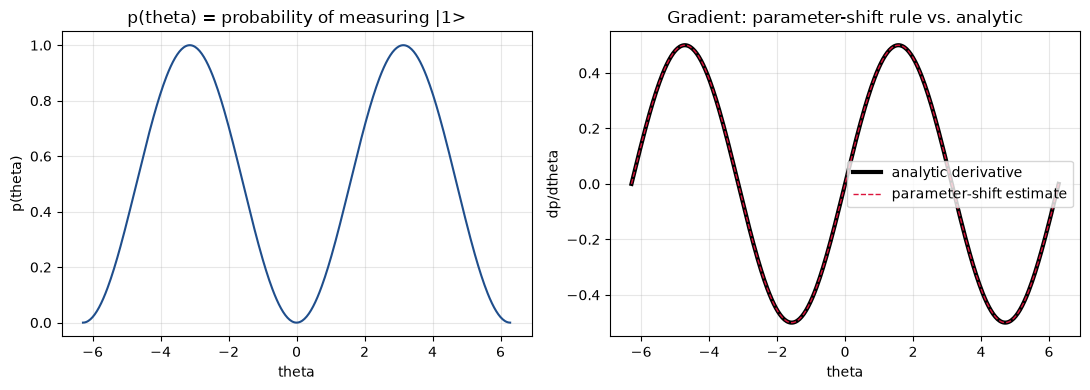

In [3]:
# ---- Plot: p(theta), and the two gradient estimates overlapping exactly ----
import matplotlib.pyplot as plt

theta_range = np.linspace(-2 * np.pi, 2 * np.pi, 400)
p_vals = p_of_theta(theta_range)
grad_shift = parameter_shift_gradient(theta_range)
grad_exact = analytic_gradient(theta_range)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(theta_range, p_vals, color='#1f4e8c')
axes[0].set_title('p(theta) = probability of measuring |1>')
axes[0].set_xlabel('theta'); axes[0].set_ylabel('p(theta)'); axes[0].grid(alpha=0.3)

axes[1].plot(theta_range, grad_exact, color='black', linewidth=3, label='analytic derivative')
axes[1].plot(theta_range, grad_shift, color='crimson', linewidth=1, linestyle='--',
             label='parameter-shift estimate')
axes[1].set_title('Gradient: parameter-shift rule vs. analytic')
axes[1].set_xlabel('theta'); axes[1].set_ylabel("dp/dtheta"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/stage00_parameter_shift_verification.png', dpi=150)
plt.show()


### 3.3 Adam Optimizer

**General idea:** Once we have a gradient $\partial \mathcal{L}/\partial \theta_i$ (from the parameter-shift rule above) for every parameter, we need a rule for actually updating $\theta_i$ at each training step. The simplest option, vanilla gradient descent, uses one fixed learning rate for every parameter, every step — this is fragile when different parameters need very different step sizes, or when the gradient itself is noisy (as it is here: quantum measurement outcomes carry shot noise). **Adam** ("Adaptive Moment Estimation") fixes this by keeping a running, decaying average of both the gradient itself and the *squared* gradient for each parameter individually, and using those to automatically scale the step size per parameter.

**The general math:** at each training step $t$, given the current gradient $g_t = \partial \mathcal{L}/\partial \theta$:

$$
\begin{aligned}
m_t &= \beta_1 m_{t-1} + (1-\beta_1)\, g_t &&\text{(first moment — momentum)} \\
v_t &= \beta_2 v_{t-1} + (1-\beta_2)\, g_t^2 &&\text{(second moment — adaptive scaling)} \\
\hat m_t &= \dfrac{m_t}{1-\beta_1^{\,t}} &&\text{(bias-corrected first moment)} \\
\hat v_t &= \dfrac{v_t}{1-\beta_2^{\,t}} &&\text{(bias-corrected second moment)} \\
\theta_{t+1} &= \theta_t \;-\; \eta \cdot \dfrac{\hat m_t}{\sqrt{\hat v_t} + \epsilon} &&\text{(parameter update)}
\end{aligned}
$$

Typical hyperparameters (and what this project uses, matching the base paper): $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$, learning rate $\eta$ small (e.g. 0.01–0.1).

**Why Adam specifically (not plain SGD)?** Quantum measurement is inherently statistical — even the *exact* parameter-shift gradient is evaluated from a finite number of shots on real/noisy hardware, so gradient estimates fluctuate run to run. Adam's momentum term smooths out this noise across iterations, and its per-parameter adaptive scaling means rotation angles that need small careful steps and angles that need large steps are each handled correctly, without manual tuning. This is exactly why the base paper (Section II-B) selects Adam over plain gradient descent for training the ansatz.

**Role in this project:** Adam is the outer loop of `04_classical_training.ipynb` — it consumes the parameter-shift gradient vector every iteration and updates all rotation angles $\theta_i$ simultaneously, repeating until the MSE loss plateaus (this is exactly what the training-convergence plots from Review 1 show: loss dropping from a rough initial value down to a flat minimum over ~150 iterations). The same Adam machinery — potentially swapped out for SPSA or Bayesian Optimization — is also what powers the project's novelty: the automated hardware/noise retuning loop in `06_hardware_retuning.ipynb`.


In [4]:
# ---- Demonstration: parameter-shift gradients + Adam, put together into one mini training loop ----
# Toy problem: train a single Ry(theta) qubit so p(theta) hits a target probability p_star.
# This is a 1-parameter miniature of exactly what Stage 4 will do with many parameters.

def adam_train(p_star=0.7, theta_init=0.1, n_iterations=150,
                lr=0.2, beta1=0.9, beta2=0.999, eps=1e-8):
    theta = theta_init
    m, v = 0.0, 0.0
    loss_history, theta_history = [], []

    for t in range(1, n_iterations + 1):
        p = p_of_theta(theta)
        loss = (p - p_star) ** 2
        loss_history.append(loss)
        theta_history.append(theta)

        # gradient of the loss w.r.t. theta, via the parameter-shift rule + chain rule
        dp_dtheta = parameter_shift_gradient(theta)
        grad = 2 * (p - p_star) * dp_dtheta

        # Adam update
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad ** 2
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)
        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)

    return theta, loss_history, theta_history

target_p = 0.7
final_theta, loss_history, theta_history = adam_train(p_star=target_p)

print(f"Target probability p* = {target_p}")
print(f"Final theta after training = {final_theta:.4f}")
print(f"Final p(theta)              = {p_of_theta(final_theta):.4f}")
print(f"Final loss                  = {loss_history[-1]:.8f}")


Target probability p* = 0.7
Final theta after training = 1.9816
Final p(theta)              = 0.6997
Final loss                  = 0.00000012


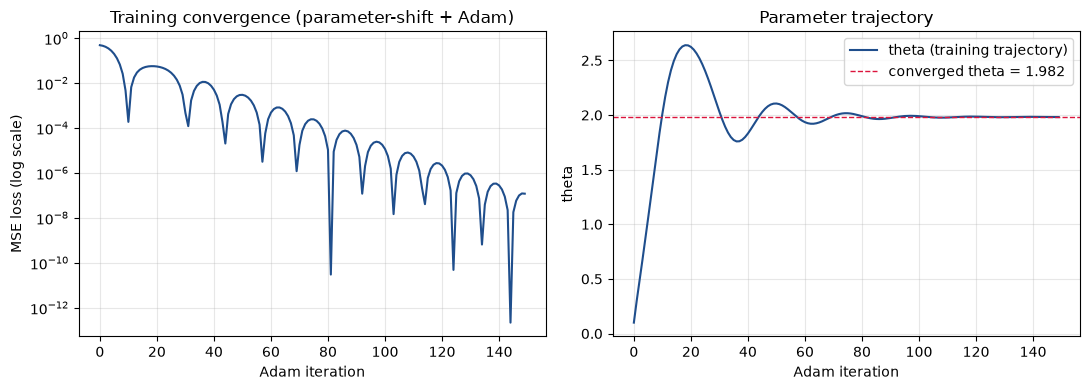

In [5]:
# ---- Plot the training convergence: exactly the shape of curve Stage 4 will produce ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(loss_history, color='#1f4e8c')
axes[0].set_yscale('log')
axes[0].set_xlabel('Adam iteration'); axes[0].set_ylabel('MSE loss (log scale)')
axes[0].set_title('Training convergence (parameter-shift + Adam)')
axes[0].grid(alpha=0.3)

axes[1].plot(theta_history, color='#1f4e8c', label='theta (training trajectory)')
axes[1].axhline(final_theta, color='crimson', linestyle='--', linewidth=1,
                 label=f'converged theta = {final_theta:.3f}')
axes[1].set_xlabel('Adam iteration'); axes[1].set_ylabel('theta')
axes[1].set_title('Parameter trajectory'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/stage00_adam_training_demo.png', dpi=150)
plt.show()


### 3.4 How the Three Algorithms Combine — Implementation Steps

The demo above trained a *single* toy parameter. The real system (Stage 4 onward) does exactly the same loop, just with several parameters at once and the actual Gaussian-loading ansatz from Section 3.1:

1. **Build the ansatz** (Stage 3): construct the $R_y$ + CNOT circuit for the chosen qubit count.
2. **Initialize** all rotation angles $\boldsymbol{\theta}$ randomly.
3. **Evaluate the circuit**: compute $p_b(\boldsymbol{\theta})$ for every basis state $b$ — via exact statevector simulation (Stage 4) or via measurement shots on `AerSimulator` (Stages 6–7).
4. **Compute the loss** $\mathcal{L}(\boldsymbol{\theta})$ against the target histogram from `01_classical_gci_model.ipynb`.
5. **For every parameter $\theta_i$**, evaluate the circuit twice more at $\theta_i \pm \pi/2$ to get the parameter-shift gradient $\partial p_b/\partial \theta_i$, and combine via the chain rule into $\partial \mathcal{L}/\partial \theta_i$.
6. **Feed the full gradient vector into Adam**, which updates every $\theta_i$ simultaneously.
7. **Repeat steps 3–6** until the loss plateaus (paper reports convergence in roughly 150 iterations for both the 2-qubit and 3-qubit loaders).
8. **The final trained $\boldsymbol{\theta}$** is what gets carried forward into transpilation (Stage 5) and hardware/noise-aware retuning (Stage 6) — and, per this project's novelty, into an automated SPSA/Bayesian recalibration loop that reuses this exact same gradient/update machinery under noise.


## 4. Project Objectives

- **Objective 1:** Implement a parameterized, hardware-efficient Variational Quantum Circuit (VQC Ansatz) on a simulator to model discrete 2-qubit and 3-qubit standard Gaussian curves.

- **Objective 2:** Construct a hybrid optimization engine linking the quantum circuit to a classical stochastic gradient descent routine (Adam Optimizer).

- **Objective 3:** Deploy the Parameter-Shift Rule directly within the circuit execution loop to extract analytical gradients without relying on classical backpropagation.

- **Objective 4:** Emulate realistic NISQ defects (readout bit-flips and depolarizing noise) and demonstrate how adaptive, in-situ gate updates successfully recover a high-fidelity Cumulative Distribution Function (CDF).


## 5. System Architecture & Novelty

The diagram below shows the full pipeline end to end, including where this project's core novelty sits.

![System Architecture](images/architecture_flowchart.png)

### What's novel here

The base paper's biggest self-acknowledged limitation (Section V) is that its in-situ retuning is a **manual, brute-force degree-by-degree grid sweep**, done by hand, per qubit pair, and explicitly *not* something that scales automatically as more risk factors/assets are added. That is the gap targeted here — algorithmically, not by claiming better hardware:

1. **Closed-Loop Auto-Calibration (replacing the manual grid sweep):** Instead of hand-sweeping θ in fixed-degree steps and eyeballing the best histogram, an **automated classical optimization loop** (SPSA / Bayesian Optimization) directly minimizes the Hellinger distance between the noisy-simulator output and the target distribution. The retuning that took a manual 21°→1° grid search in the base paper becomes a repeatable, scriptable function call.

2. **Scaling Beyond the Toy Model:** The base paper only *analytically projects* the resource cost of a 2-asset/2-risk-factor model (6 qubits) — it never actually builds or simulates one. This project implements and simulates that scaled circuit directly, empirically measuring how training difficulty, circuit depth, and noise sensitivity grow, rather than relying on linear extrapolation.

3. **Quantitative Noise-Mitigation Comparison:** The base paper applies noise correction only through in-situ angle retuning. This project additionally benchmarks standard **error-mitigation techniques available in Qiskit** — readout error mitigation and Zero-Noise Extrapolation (ZNE) — measuring their individual and combined effect on Hellinger fidelity and VaR accuracy, something the base paper explicitly lists as unimplemented future work.

4. **Noise-Aware Training (stretch goal):** Rather than the base paper's strict two-phase approach (train noiseless → retune on hardware after the fact), the noise model can also be injected *during* training itself, to test whether a circuit trained with noise-awareness from the start needs less post-hoc retuning.

> The result is an **automated, noise-aware calibration algorithm** that replaces manual grid-search retuning — evaluated on a noise-emulated simulator, with no claim of physical QPU deployment.


## 6. Reference

H. G. Ahmad, A. Sarno, M. El Bakraoui, C. Cosenza, C. Bésoin, F. Cibrario, V. Zaffaroni, G. Ranieri, R. Bertilone, V. Stasino, P. Mastrovito, F. Tafuri, D. Massarotti, L. Chabbra, and D. Corbelletto, "Quantum Circuit-Based Adaptation for Credit Risk Analysis," *IEEE Transactions on Quantum Engineering*, vol. 7, Art. no. 3103316, 2026, doi: [10.1109/TQE.2026.3691176](https://doi.org/10.1109/TQE.2026.3691176).


## 7. Full Project Roadmap (all 9 stages)

| Stage | Notebook | What happens |
|---|---|---|
| 0 | `00_overview.ipynb` | Problem statement, gaps in the base paper, algorithmic framework, objectives, novelty |
| 1 | `01_classical_gci_model.ipynb` | Classical Vasicek/GCI baseline: PD(z), discretized target histograms, classical Monte Carlo VaR |
| 2 | `02_quantum_encoding.ipynb` | Linearize PD(z) ≈ sin²(αz + β); derive the R<sub>y</sub> rotation mapping |
| 3 | `03_circuit_design.ipynb` | Build the full circuit: z-register (R<sub>y</sub> + CNOT) + asset qubit (controlled-R<sub>y</sub>) |
| 4 | `04_classical_training.ipynb` | Train ansatz angles against the Stage 1 target histograms via parameter-shift rule + Adam |
| 5 | `05_transpilation.ipynb` | SABRE routing/layout to a mock hardware coupling map |
| 6 | `06_hardware_retuning.ipynb` | In-situ angle adaptation on a noisy simulator — baseline manual sweep **and** the automated SPSA/Bayesian novelty |
| 7 | `07_run_on_backend.ipynb` | Execute on `AerSimulator` + noise model, thousands of shots |
| 8 | `08_classical_postprocessing.ipynb` | Bitstrings → loss PDF → CDF |
| 9 | `09_var_fidelity_check.ipynb` | Extract 95% VaR, compute Hellinger fidelity vs. the Stage 1 classical benchmark |

---
*Next: → `01_classical_gci_model.ipynb`*
